# Part 1

# TODO: Possibly add prediction error, check all parts are complete, figure out why line is below where it should be, verify in Colab


I used ChatGPT to understand the formulas given in the Linear Regression Optional Reading. I also used it to generate examples of linear regression from a theoretical standpoint in order to better understand the content. All code is my own

I first spent time understanding linear regression better. I read through the optional reading multiple times, and I asked ChatGPT to explain the variables in the mathematical equation. It took some time before I understood the proof behind the given algorithm. After that, I wrote it in Python on my own. On my first attempt, I failed to sum the errors across all data points. After fixing that, the model still did not work. I checked each line individually and found that I accidentally subracted instead of added in one location. 

h(x) = 1.7095936444387765e-07x + -139.9240509797051

I display several plots underneath my code, including the loss graph, slope and bias graphs, and the training and test data with the line of best fit marked. 

In [16]:
!pip install matplotlib
!pip install numpy

In [17]:
import matplotlib.pyplot as plt
import numpy as np

In [52]:
# Define learn function

def learn(num_iter, x_train, y_train):
    alpha = 0.001
    slope = 1 # Seed value
    slope_history = []
    bias_history = []
    error_history = []
    bias = 1 # Seed value
    params = np.array([slope, bias])

    j = 0

    while j < num_iter:
        x_j_input = x_train[j % len(x_train)]
        input_j = np.array([x_j_input, 1]) # Use 1 as the x input val for bias

        # Calculate sum of loss
        loss_sum = 0
        for n in range(len(x_train)):
            pred_val = np.sum(params * input_j) 
            loss = (y_train[n] - pred_val)
            loss_sum = loss_sum + loss
            loss_sum_scaled = loss_sum * input_j

        error_history.append(loss_sum)
        # Update theta
        params = params + alpha * loss_sum_scaled
        slope_history.append(params[0])
        bias_history.append(params[0])

        j = j + 1
    
    return params[0], params[1], slope_history, error_history, loss_sum


In [19]:
# Load Data

x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")
x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

In [20]:
learned_slope, bias, slope_history, error_history = learn(200, x_train, y_train)
print(f"Learned slope: {learned_slope}")
print(f"Learned bias: {bias}")
print(f"Equation: h(x) = {learned_slope}x + {bias}")

Learned slope: 1.7095936444387765e-07
Learned bias: -139.9240509797051
Equation: h(x) = 1.7095936444387765e-07x + -139.9240509797051


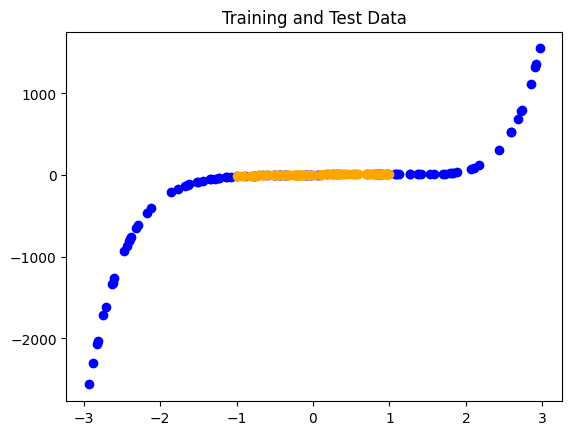

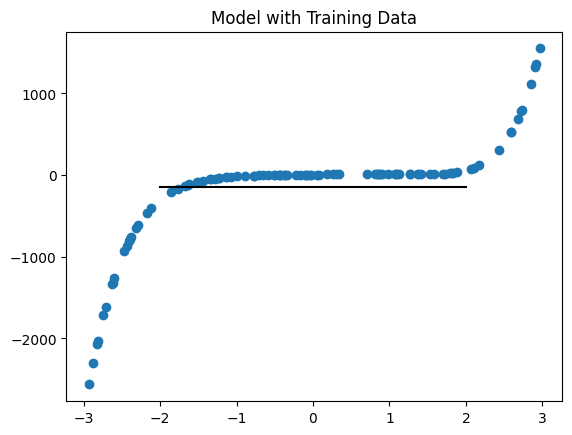

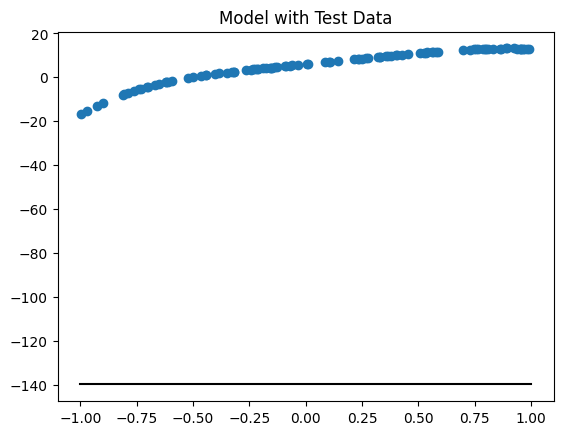

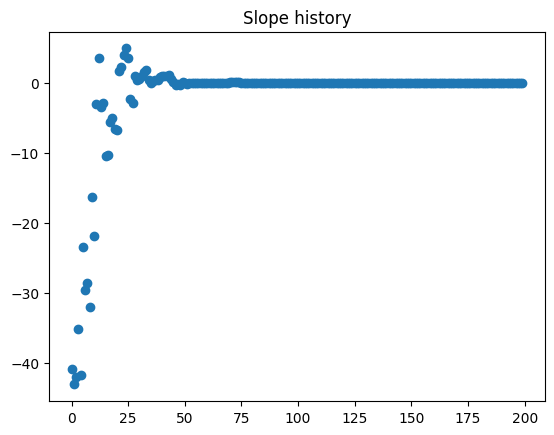

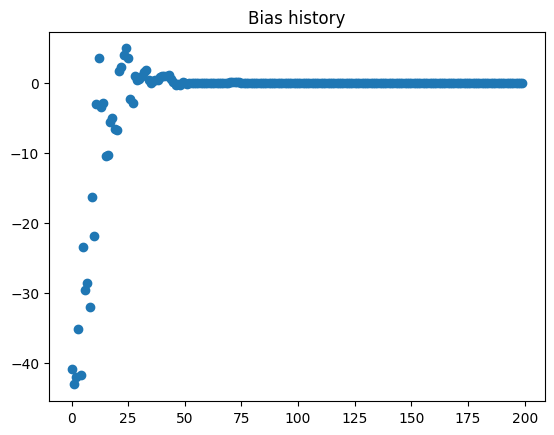

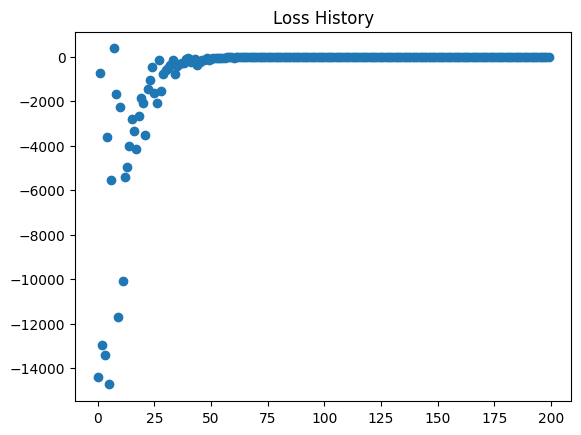

In [21]:
# Show results

plt.scatter(x_train, y_train, color="blue")
plt.scatter(x_test, y_test, color="orange")
plt.title("Training and Test Data")
plt.show()

plt.scatter(x_train, y_train)
plt.plot([-2, 0,2], [bias - 2 * learned_slope, bias, bias + 2 * learned_slope], color="black")
plt.title("Model with Training Data")
plt.show()

plt.scatter(x_test, y_test)
plt.plot([-1, 0,1], [bias - learned_slope, bias, bias + learned_slope], color="black")
plt.title("Model with Test Data")
plt.show()

plt.scatter([i for i in range(0, len(slope_history))], slope_history)
plt.title("Slope history")
plt.show()

plt.scatter([i for i in range(0, len(slope_history))], slope_history)
plt.title("Bias history")
plt.show()

plt.title("Loss History")
plt.scatter([i for i in range(0, len(error_history))], error_history)
plt.show()

# Part 2

## Status: working on loading CSVs correctly, then planning on running "learn" function on one to get it to work, then find a way to return a predicted error or other metric and run on all in loop, and pick the best fit one

In [22]:
import matplotlib.pyplot as plt
import numpy as np



 id
Learned slope: 10350071733913.27
Learned bias: 657019726607.8246
Equation: h(x) = 10350071733913.27x + 657019726607.8246
Loss is 591619528218993.2


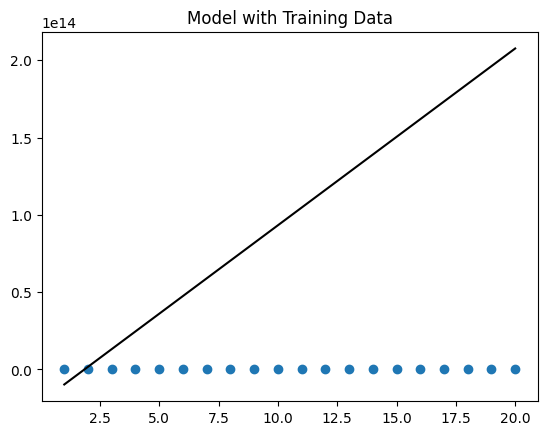



 baths
Learned slope: 2.1527681799166976
Learned bias: 3.689722201750217
Equation: h(x) = 2.1527681799166976x + 3.689722201750217
Loss is 15.78145038193928


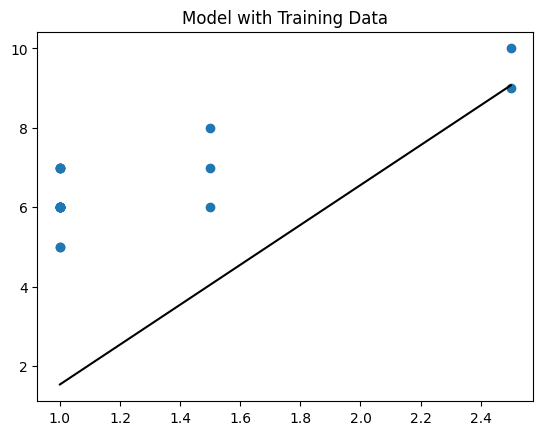



 land
Learned slope: 0.4281613875771456
Learned bias: 3.181586941768229
Equation: h(x) = 0.4281613875771456x + 3.181586941768229
Loss is -6.65153156024828


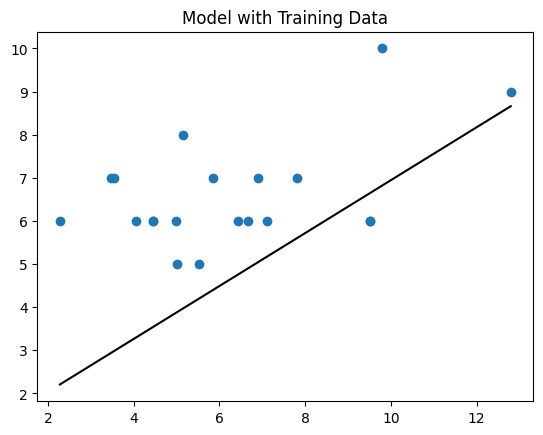



 living
Learned slope: 1.72074655943638
Learned bias: 3.735932872714665
Equation: h(x) = 1.72074655943638x + 3.735932872714665
Loss is 6.052348409214233


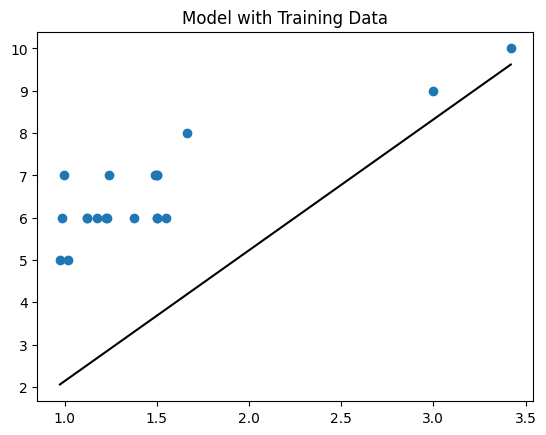



 garages
Learned slope: 1.5217754118067872
Learned bias: 4.390774693552948
Equation: h(x) = 1.5217754118067872x + 4.390774693552948
Loss is -1.570862273008082


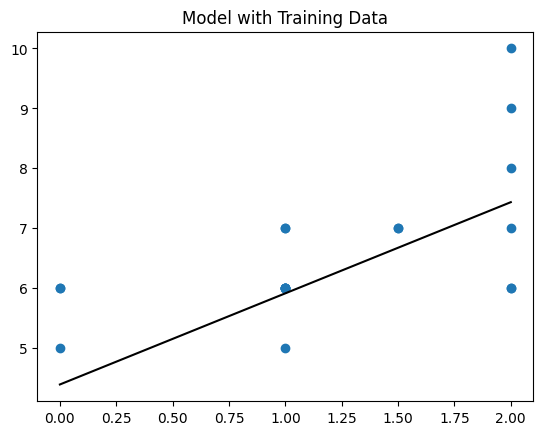



 rooms
Learned slope: 0.7639055407603351
Learned bias: 1.2526612146776543
Equation: h(x) = 0.7639055407603351x + 1.2526612146776543
Loss is -13.144433074307493


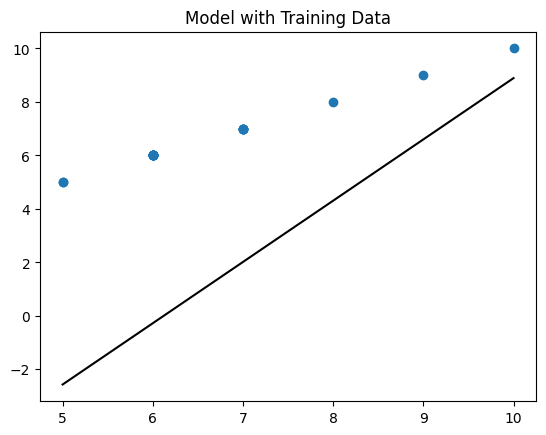



 beds
Learned slope: 1.3854488190540712
Learned bias: 2.1796251410222176
Equation: h(x) = 1.3854488190540712x + 2.1796251410222176
Loss is 6.600710045389231


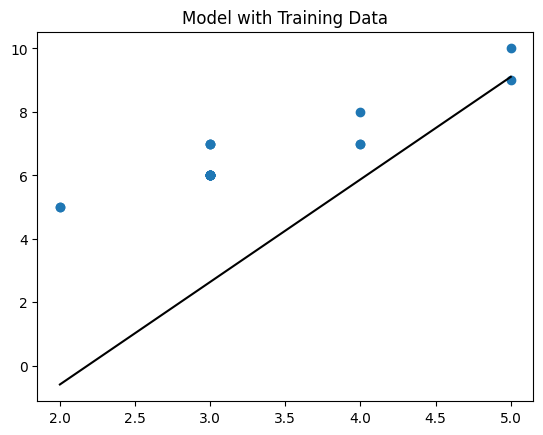



 age
Learned slope: 1.860524258257355e+272
Learned bias: 7.750052587552666e+270
Equation: h(x) = 1.860524258257355e+272x + 7.750052587552666e+270
Loss is 8.931158013707228e+273


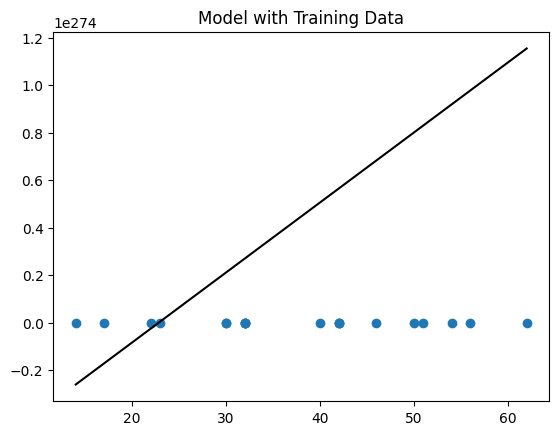

In [56]:
data_formats = {'names': ('id', 'baths', 'land', 'living', 'garages', 'rooms','beds','age', 'price'), 'formats':('i2', 'f2', 'f4','f4', 'f4', 'i4', 'i4','i4','f8')}
housing_train = np.loadtxt("train.csv", delimiter=',', skiprows=1, dtype=data_formats)
housing_test = np.loadtxt("test.csv", delimiter=',', skiprows=1, dtype=data_formats)
#House ID,Bathrooms,Land Area,Living area,# Garages,# Rooms,# Bedrooms,Age of home,Price


housing_train_output = housing_train["rooms"]

for n in data_formats["names"]:
    if n == 'price':
        continue
    print("\n\n", n)
    housing_train_input = housing_train[n]
    learned_slope, bias, slope_history, error_history, final_loss = learn(200, housing_train_input, housing_train_output)
    print(f"Learned slope: {learned_slope}")
    print(f"Learned bias: {bias}")
    print(f"Equation: h(x) = {learned_slope}x + {bias}")
    print(f"Loss is {final_loss}")

    plt.scatter(housing_train_input, housing_train_output)
    first_x = np.min(housing_train_input)
    last_x = np.max(housing_train_input)
    plt.plot([first_x, last_x], [bias - first_x * learned_slope, bias + last_x * learned_slope], color="black")
    plt.title("Model with Training Data")
    plt.show()